## **SUMMARY**
This script is used to attribute point data into building footprints. 

Census data and footprints are preprocessed in a separate script. 



### **REQUIRED INPUTS**
Point data in any format that can be loaded as a pandas gdf 

In [1]:
# Copyright (c) 2025, Meredith Lochhead
# All rights reserved.
#
# This source code is licensed under the BSD 3-Clause License found in the
# LICENSE file in the root directory of this source tree.

In [2]:
# Relevant python functions
import pandas as pd
# import numpy as np
import geopandas as gpd
import os
import sys
import matplotlib.pyplot as plt
import contextily as ctx
import folium
from matplotlib.patches import Patch

# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)

import functions_general as fxns
import functions_point_to_ftpt as pt_ftpt

In [3]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]


In [4]:
# Target Directory 
directory = './Results/'

# Make directory and intermediate directory
os.makedirs(directory, exist_ok=True)
dir_intermediate = directory + 'Intermediate/'
os.makedirs(dir_intermediate, exist_ok=True)

## **Load Baseline Geometry (Footprints) and Bounding Geometry (Census Blocks)**

In [5]:
# Load building footprints 
footprints = fxns.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json', crs_main)

# Load Census blocks and tracts
blocks = gpd.read_file('./Input_Data/Census/Census2020/Hayward_blocks.geojson')
tracts = gpd.read_file('./Input_Data/Census/Census2020/Hayward_tracts.geojson')

# Create CensusBlock column 
geoid = 'GEOID20'
blocks['CensusBlock'] = blocks[geoid] 

## **Preprocess Point Data**

In [6]:
# Load point data
## NOTE: If data is in a different format, you will need to change this line of code to whatever is needed to load your data as a Pandas GeoDataframe
points = gpd.read_file('./Input_Data/Points.geojson')
points = points.to_crs(epsg=crs_main)

### **Remove exact duplicates**

In [7]:
### CLEAN ADDRESS DATA AND PREPARE FOR MERGE WITH SCRAPED DATA ###

# Remove exact duplicates from point data
print('All Points:',len(points))
points = points.drop_duplicates() # Remove exact duplicates
print('After exact duplicates:',len(points))

All Points: 82047
After exact duplicates: 82047


### **Trim to study boundaries**

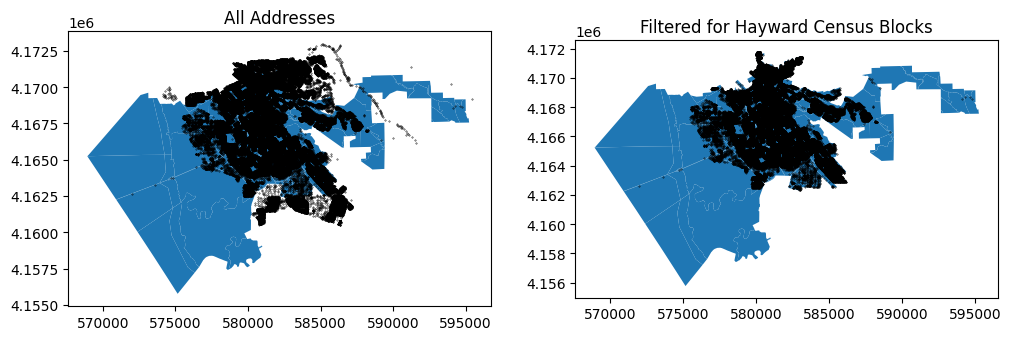

In [8]:
# Trim to study boundaries 

# Plot
fig, ax = plt.subplots(1,2, figsize = (12, 12))
blocks.plot(ax=ax[0])
points.plot(ax=ax[0], color ='black', markersize = 0.1)
ax[0].set_title('All Addresses')

# Assign block to points
points_copy = points.copy()
points_copy = points_copy.sjoin(blocks, how='left')
points.loc[:, 'CensusBlock'] = points_copy[geoid].values

# Assign tract to points
points_copy = points.copy()
points_copy = points_copy.sjoin(tracts, how='left')
points.loc[:, 'CensusTract'] = points_copy[geoid].values

# Drop rows that are not in blocks of interest
points = points[~points['CensusBlock'].isna()].copy()

# Plot to check 
blocks.plot(ax=ax[1])
points.plot(ax=ax[1], color ='black', markersize = 0.1)
ax[1].set_title('Filtered for Hayward Census Blocks')
plt.show()

### **Drop unncessary columns**

In [9]:
### DROP COLUMNS THAT DO NOT NEED TO BE REATINED THROUGHOUT INVENTORY GENERATION ###
columns_to_drop = ['Address_ID','APN_GIS','Status','Affordability_Level','Affordable','Pre_Type','Zone','SitusAddress','OBJECTID',
                   'HouseNum', 'Prefix', 'Pre_Type','Street_Name', 'Street_Type', 'Suffix_Dir', 'House_Unit', 'City',
                    'State', 'Zipcode', 'Zone', 'FullAddress', 'AddrUnit_Type','SubtypeField','LonTxt_X','LatTxt_Y']
points = points.drop(columns=columns_to_drop)

## **Attribute Points to Footprints**

In [10]:
## SETTINGS FOR "NOT FULL FOOTPRINT" DESIGNATION DURING MERGE PROCESS

## Set flag to determine if using "not full footprints" as a tool to prioritize footprint attribution. 
# This is recommended (set to true) if most points in the data represent single buildings. 
# It is not recommended (set to false) if most points represent single units (i.e., one condo within a larger building). 
# Generally, if not using NSI data, set this to False
use_size_limit = False


## IF use_size_limit IS TRUE: 
    # Compute square footage to be used for "not full footprint" designation during merge process
    # If most footprints have FootprintHeight available (in feet), set estimate_stories = True
    # If most footprints do not have FootprintHeight available, using height to designate if a footprint is not full may cause bias, and it is better to just use FootprintArea (set estimate_stories = False)
estimate_stories = False
footprints = pt_ftpt.estimate_ftpt_size_for_merge(footprints.copy(),estimate_stories)

In [ ]:

##### DISPLAY NUMBER OF POINTS #####
points_length = len(points) # Used for tracking purposes 
print('Points:', len(points))
print('Footprints:', len(footprints))

NSI: 63168
Footprints: 38300


In [12]:
##### CREATE TRACKING COLUMNS TO BE USED IN FOOTPRINT MERGE #####
points['POINT_ID'] = range(len(points)) # This is an ID number that is used throughout the script to refer to each row
points['POINT_FootprintID'] = pd.Series([pd.NA] * len(points), dtype='Int64') #None # This is the FootprintID that will be paired witht the point data throughout
points['DistanceToFtpt'] = None 
points['ClosestFtpt_ID'] = None
points['POINT_ID_List'] = points['POINT_ID'] # This tracks the ID numbers associated with that row 
points['POINT_NumPoints'] = 1 # This tracks the number of points consolidated into the single row 
points['POINT_MergeFlag'] = 0 # This tracks at what stage the point and footprint are merged


##### CREATE ADDITIONAL COLUMNS TO BE USED IN FOOTPRINT MERGE #####
points['POINT_DropFlag'] = 0 # This indicates whether a row should be dropped from the final inventory. 1 indicates yes, 0 indicates no 
points['POINT_DropNote'] = "" # Space for notes on the reason data points are dropped 
points['POINT_Source'] = 'AddressPoints' # This tracks the original data source for each row 
points['POINT_DataUpdate'] = "" # Space for notes on steps throughout update 


In [13]:
### DEFINE COLUMNS TO BE SUMMED OR COVERTED TO LISTS WHEN COMBINED ### 
# sum_columns get summed when points are merged (i.e. replacement cost)
# list_columns get put into lists (if information differs) when points are merged (i.e. foundation type)

# Set category of certain column names
excluded = ['geometry', 'CensusBlock', 'CensusTract', 'POINT_DropFlag', 'POINT_DropNote','POINT_ID',
            'POINT_FootprintID', 'DistanceToFtpt', 'ClosestFtpt_ID', 'POINT_MergeFlag','POINT_DataUpdate']
sum_columns = ['POINT_NumPoints']
list_columns = ['FeatureCode', 'APN_PQ','POINT_Source','POINT_ID_List']

# Print unassigned columns 
fxns.check_column_assignment(points, sum_columns, list_columns, excluded)

    

No Unassigned Columns


### **MergeFlag1 - Cases with 1 Footprint and 1 Point**

In [14]:
##### SPLIT DATA BASED ON DROP_FLAG #####
points0 = points[points['POINT_DropFlag']!=1] # Not dropped - these should be used in merge
points1 = points[points['POINT_DropFlag']==1] # Dropped - these should not be used in merge 

##### RUN FUNCTION TO MERGE CASES WITH ONE POINT WITHIN ONE FOOTPRINT #####
plot_overlap_flag = False # Plots cases where a point is associated with multiple footprints (which is a problem) 
points0, map = pt_ftpt.merge_intersecting(points0, footprints, crs_plot, plot_overlap_flag)

# Plot overlapping footprints if found  # TODO TAKE OUT -- NOW IN PREPROCESSING 
if isinstance(map, str):
    print(map)
else: 
    display(map)

# # Update MergeFlag99 for footprints that are larger than their designated occupancy type 
if use_size_limit:
    points0 = pt_ftpt.update_mergeflag99(points0, footprints, mergeflag = 1)

##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
points = pt_ftpt.recombine_dropped_data(points0, points1, points_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
pt_ftpt.check_post_merge_duplicates(points.copy())

##### SAVE JSON FILE #####
fxns.gdf_to_json(points.copy(), dir_intermediate + 'MergeFlag1.json')


Points within Footprints: 55765
Unique points within Footprints (one point per footprint): 26635
Data with Associated Footprints (should match row above): 26635
Passed Check: No overlapping footprints found
Passed Check: No duplicates found
JSON File Saved


In [15]:
# # ### UNCOMMENT CODE TO PLOT MAP WITH FOOTPRINTS AND POINTS
# points = fxns.json_to_gdf(dir_intermediate + '/MergeFlag1.json', crs_main)
# remaining = points[(points['POINT_DropFlag']!=1) & (points['POINT_FootprintID'].isna())]
# print(len(remaining))
# fig, ax = plt.subplots(figsize=(30,30))
# footprints.plot(ax=ax, color = 'gray', alpha = 0.3)
# remaining.plot(ax=ax, markersize = 1)
# plt.show()

In [16]:
# # ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND POINTS
# points = fxns.json_to_gdf(dir_intermediate + '/MergeFlag1.json', crs_main)
# remaining = points[(points['POINT_DropFlag']!=1) & (points['POINT_FootprintID'].isna())]
# print(len(remaining))

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in remaining.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)

# # display(m)

### **MergeFlag2 - Address Cases with 1 Footprint and Multiple Points**

In [17]:
##### LOAD DATA #####
points = fxns.json_to_gdf(dir_intermediate + 'MergeFlag1.json', crs_main)


##################################################################################################################################

############# THE FOLLOWING CAN BE FILLED OUT TO MAKE MODIFICATIONS BASED ON THE PRINTED OUT "ODD OCCUPANCY PAIRINGS" #################

##### MANUALLY ASSIGN OCCUPANCY CLASS FOR FOOTPRINTS HERE #####
manually_assigned_occupancy_data = {
    "FootprintID":[], # Put FootprintID values in this list
    "POINT_OccupancyClass":[]} # Put corresponding occupancy class values in this list. Can enter string or list, 
                             # i.e. "NSI_OccupancyClass":['RES1',['IND3','RES3C]] would correspond to first and second FootprintID entered in list above
manually_assigned_occupancy = pd.DataFrame(manually_assigned_occupancy_data)

##### MANUALLY DROP NSI POINTS HERE #####
ids_to_drop = [] # Place NSI_ID values here that should be dropped from the merge 
points = pt_ftpt.drop_ids(points, ids_to_drop, 'Manually dropped due to occupancy class incompatibility')

##################################################################################################################################


##### SPLIT DATA BASED ON DROP_FLAG #####
points0 = points[points['POINT_DropFlag']!=1] # Not dropped - these should be used in merge
points1 = points[points['POINT_DropFlag']==1] # Dropped - these should not be used in merge 


#### RUN FUNCTION TO MERGE CASES WITH MULTIPLE POINTS WITHIN ONE FOOTPRINT #####
# Set flag to print odd occupancy pairings, including (RES + IND), (RES + GOV), and (EDU + IND) - does not change function outputs, only displays 
print_odd_occupancy_pairings = False
use_nsi_occupancy_merge = False
points0 = pt_ftpt.address_overlapping_points(points0.copy(), footprints.copy(), list_columns, sum_columns, manually_assigned_occupancy,use_size_limit, use_nsi_occupancy_merge, print_odd_occupancy_pairings, crs_plot)

##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
points = pt_ftpt.recombine_dropped_data(points0, points1, points_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
points['POINT_FootprintID'] = points['POINT_FootprintID'].astype('Int64')
pt_ftpt.check_post_merge_duplicates(points.copy())

##### SAVE JSON FILE #####
fxns.gdf_to_json(points.copy(), dir_intermediate + 'MergeFlag2.json')

Number of Points Remaining: 36533
Number of Footprints Remaining: 11665
Number of Points within Footprint Polygons: 29151
Number of Footprints with Multiple Points (Looping Through These Now): 4316
10% complete
20% complete
30% complete
40% complete
50% complete
60% complete
70% complete
80% complete
90% complete
100% complete
Passed Check: No duplicates found
JSON File Saved


In [18]:
# # ### UNCOMMENT CODE TO PLOT MAP WITH FOOTPRINTS AND POINTS
# points = fxns.json_to_gdf(dir_intermediate + '/MergeFlag2.json', crs_main)
# remaining = points[(points['POINT_DropFlag']!=1) & (points['POINT_FootprintID'].isna())]
# print(len(remaining))
# fig, ax = plt.subplots(figsize=(30,30))
# footprints.plot(ax=ax, color = 'gray', alpha = 0.3)
# remaining.plot(ax=ax, markersize = 1)
# plt.show()

In [19]:
# # ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND POINTS
# points = fxns.json_to_gdf(dir_intermediate + '/MergeFlag2.json', crs_main)
# remaining = points[(points['POINT_DropFlag']!=1) & (points['POINT_FootprintID'].isna())]
# print(len(remaining))

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in remaining.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)

# display(m)

### **MergeFlag310 - Merge Points within 10m of a Footprint**

In [20]:
# Load data 
points = fxns.json_to_gdf(dir_intermediate + '/MergeFlag2.json', crs_main)


##################################################################################################################################

############# THE FOLLOWING CAN BE FILLED OUT TO MAKE MODIFICATIONS BASED ON THE PRINTED OUT "ODD OCCUPANCY PAIRINGS" #################

##### MANUALLY ASSIGN OCCUPANCY CLASS FOR FOOTPRINTS HERE #####
manually_assigned_occupancy_data = {
    "FootprintID":[], # Put FootprintID values in this list
    "POINT_OccupancyClass":[]} # Put corresponding occupancy class values in this list. Can enter string or list, 
                             # i.e. "NSI_OccupancyClass":['RES1',['IND3','RES3C]] would correspond to first and second FootprintID entered in list above
manually_assigned_occupancy = pd.DataFrame(manually_assigned_occupancy_data)

##### MANUALLY DROP NSI POINTS HERE #####
ids_to_drop = [] # Place NSI_ID values here that should be dropped from the merge 
points = pt_ftpt.drop_ids(points, ids_to_drop, 'Manually dropped due to occupancy class incompatibility')

##################################################################################################################################


##### SPLIT DATA BASED ON DROP_FLAG #####
points0 = points[points['POINT_DropFlag']!=1].copy() # Not dropped - these should be used in merge
points1 = points[points['POINT_DropFlag']==1].copy() # Dropped - these should not be used in merge 


##### CONDUCT MERGE #####

# Get list of bounding geometries (census blocks)
bounding_id_list =  blocks['CensusBlock'].unique()
bounding_id_name = 'CensusBlock'
bounding_geometry = blocks.copy()

# Merge data using function 
points0 = pt_ftpt.distance_limit_merge(bounding_id_list, points0.copy(), footprints, bounding_id_name, manually_assigned_occupancy, list_columns, sum_columns, bounding_geometry, crs_plot,
                            distance_limit = 10, # Meters
                            use_surrounding_bgs = False, # Footprints in surrounding bounding geometries (parcels) will be considered for each NSI point
                            prioritize_empty_footprints = False, # Empty footprints within the distance limit will be prioritized over partially full or full footprints for attribution 
                            prioritize_partial_footprints = False, # Footprints with MergeFlag = 99 will be prioritized over full footprints for attribution (prioritized second to empty footprints if prioritize_empty_footprints = True)
                            use_full_footprints = True, # Full footprints will be considered for atribution (once empty and partial footprints in distance limit have been exhausted, if the above prioritize flags are set to True)
                            merge_flag = 310, 
                            use_size_limit = use_size_limit, # Use size limit to designate "partially full footprints"
                            use_nsi_occupancy_merge = False, # Set to True only if merging NSI data 
                            print_odd_occupancy_pairings = False) # If True, some occupancy class pairs will be printed out if they are merged into same footprint to manually check 


##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
points = pt_ftpt.recombine_dropped_data(points0, points1, points_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
points['POINT_FootprintID'] = points['POINT_FootprintID'].astype('Int64')
pt_ftpt.check_post_merge_duplicates(points.copy())

##### SAVE JSON FILE #####
fxns.gdf_to_json(points.copy(), dir_intermediate + 'MergeFlag310.json')


Number of Points Remaining: 7382
Number of Footprints Remaining: 7349
Processing 1488 Bounding Geometries
10% complete
20% complete
30% complete
40% complete
50% complete
60% complete
70% complete
80% complete
90% complete
100% complete
Passed Check: No duplicates found
JSON File Saved


In [21]:
## NOTE: The above cell can be repeated for any distance limit (e.g. 20 meters, 30 meters, etc.) by changing the distance_limit parameter. 
## It is recommended to run the above cell first for 10m to first handle close by data, then run it again for a larger limit (such as 100m). 

In [22]:
# # ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND POINTS
# points = fxns.json_to_gdf(dir_intermediate + '/MergeFlag310.json', crs_main)
# remaining = points[(points['POINT_DropFlag']!=1) & (points['POINT_FootprintID'].isna())]
# print(len(remaining))
# fig, ax = plt.subplots(figsize=(30,30))
# footprints.plot(ax=ax, color = 'gray', alpha = 0.3)
# remaining.plot(ax=ax, markersize = 1)
# plt.show()

In [23]:
# # ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND POINTS
# points = fxns.json_to_gdf(dir_intermediate + '/MergeFlag310.json', crs_main)
# remaining = points[(points['POINT_DropFlag']!=1) & (points['POINT_FootprintID'].isna())]
# print(len(remaining))

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)
# folium.GeoJson(blocks.copy().to_crs(crs_plot), color = 'blue').add_to(m)

    
#     # Add remaining points     
# for idx, row in remaining.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red',
#                         popup = row['FeatureCode']).add_to(m)

# display(m)

## **Drop Remaining Points and Export Data**

In [32]:
## Load data
points = fxns.json_to_gdf(dir_intermediate + '/MergeFlag310.json', crs_main)

## Drop points that are marked to be dropped 
print(len(points), 'total points processed')
points = points[points['POINT_DropFlag']!=1]
print(points['POINT_NumPoints'].sum(), 'footprints containing points')

# Drop points that were not attributed to a footprint
unpaired = points[points['POINT_FootprintID'].isna()]
points = points[points['POINT_FootprintID'].notna()]
print(len(unpaired), 'unpaired points dropped')

63168 total points processed
63168 footprints containing points
2205 unpaired points dropped


In [25]:
# Drop additional columns used for tracking purposes 
points = points.drop(columns = ['POINT_DropFlag','POINT_DropNote','DistanceToFtpt', 'ClosestFtpt_ID','POINT_ID', 'POINT_DataUpdate'])
points = points.rename(columns={'POINT_ID_List': 'POINT_ID'})

# Rename footprints 
points = points.rename(columns={'POINT_FootprintID': 'FootprintID'})

#### SAVE JSON FILE #####
fxns.gdf_to_json(points.copy(), directory + '/Point_Data_Attributed.json')

JSON File Saved


## **(If needed) Convert Point Data to Footprint Data**

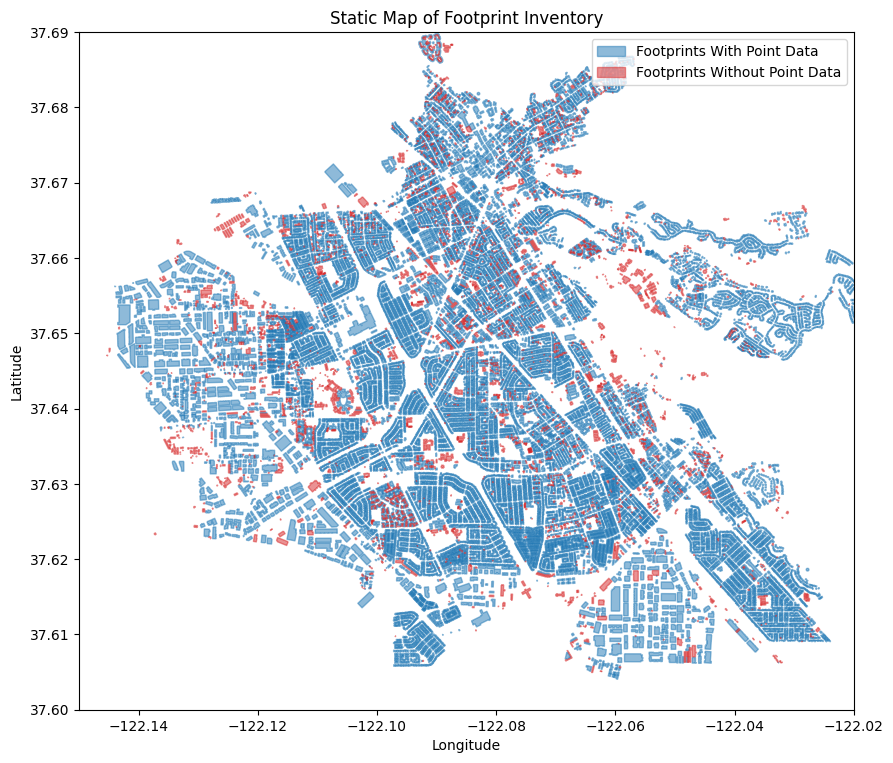

JSON File Saved


In [26]:
# Create baseline inventory 
ftpt_inv = footprints.copy()
orig_inv_length = len(ftpt_inv)
points['Point_Data_Flag'] = 1

# Drop geometry information in preparation for merge 
points = points.drop(columns = ['geometry'])

# Merge unique footprint information in with baseline footprint inventory and perform checks for dropped points
ftpt_inv = ftpt_inv.merge(points, on='FootprintID', how='left')
if len(ftpt_inv) != orig_inv_length: 
    raise ValueError('Footprints Dropped - Step 1')

if len(ftpt_inv[ftpt_inv['Point_Data_Flag']==1]) != len(points): 
    raise ValueError('Footprints Dropped - Step 2')

# Drop redundant footprint column
ftpt_inv['Point_Data_Flag'] = ftpt_inv['Point_Data_Flag'].fillna(0)

# Plot inventory
fig, ax = plt.subplots(figsize=(10,10))
ftpt_inv[ftpt_inv['Point_Data_Flag']==1].to_crs(crs_plot).plot(ax=ax, color='tab:blue', edgecolor='tab:blue', alpha=0.5, label = 'Footprints With Point Data')
ftpt_inv[ftpt_inv['Point_Data_Flag']==0].to_crs(crs_plot).plot(ax=ax, color='tab:red', edgecolor='tab:red', alpha=0.5, label = 'Footprints Without Point Data')
plt.title('Static Map of Footprint Inventory')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(xbounds)
plt.ylim(ybounds)

legend_elements = [
Patch(facecolor='tab:blue', edgecolor='tab:blue', alpha=0.5,label='Footprints With Point Data'),
Patch(facecolor='tab:red', edgecolor='tab:red', alpha=0.5,label='Footprints Without Point Data')]
ax.legend(handles=legend_elements, loc='upper right')

plt.show()

# Export footprint inventory 
fxns.gdf_to_json(ftpt_inv, './Results/Footprint_Inventory.json')

NOTE: The resulting 'Footprint_Inventory.json' can be used as a geodataframe with the geometry describing the building footprints. The column 'Point_Data_Flag' indicates whether that footprint has point data (1) or does not (0). It can be filtered using that flag if needed. 